<a href="https://colab.research.google.com/github/Shiyasalloor/Computer_Vision_Lab/blob/main/Shape_similiarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

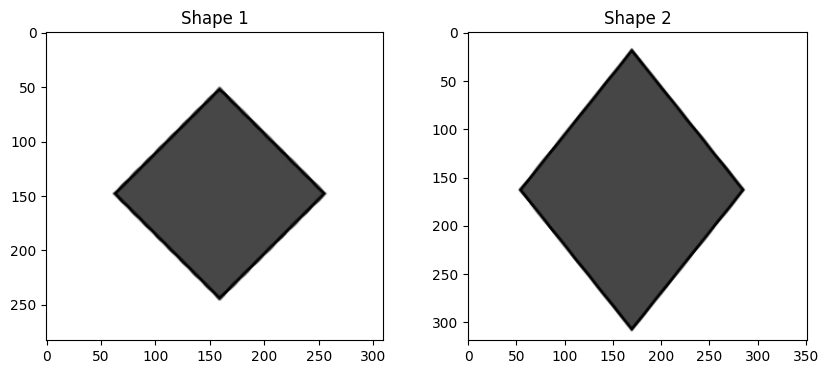

In [6]:
img1 = cv2.imread("/content/image1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/content/image2.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Shape 1")
plt.imshow(img1, cmap='gray')

plt.subplot(1,2,2)
plt.title("Shape 2")
plt.imshow(img2, cmap='gray')

plt.show()


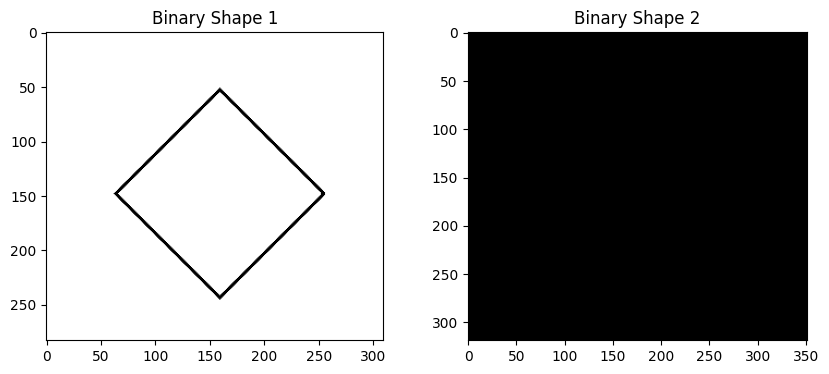

In [7]:
_, bin1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)
_, bin2 = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Binary Shape 1")
plt.imshow(bin1, cmap='gray')

plt.subplot(1,2,2)
plt.title("Binary Shape 2")
plt.imshow(bin2, cmap='gray')

plt.show()

In [8]:
moments1 = cv2.moments(bin1)
moments2 = cv2.moments(bin2)

print("Geometric Moments for Shape 1:\n")
for key, value in moments1.items():
    print(f"{key}: {value}")

print("\n---------------------------------\n")

print("Geometric Moments for Shape 2:\n")
for key, value in moments2.items():
    print(f"{key}: {value}")


Geometric Moments for Shape 1:

m00: 21981510.0
m10: 3394390935.0
m01: 3096665430.0
m20: 702123644535.0
m11: 478175459655.0
m02: 584346123630.0
m30: 163410214157985.0
m21: 98922188454255.0
m12: 90237759502125.0
m03: 124078003959930.0
mu20: 177960844999.8373
mu11: -12483953.9639236
mu02: 148100534252.5148
mu30: 26557058743.772987
mu21: 13730082796.15625
mu12: 6384692354.34375
mu03: 30108734892.4972
nu20: 0.0003683065259098856
nu11: -2.5836704214771795e-08
nu02: 0.0003065078346643702
nu30: 1.1722929893357195e-08
nu21: 6.0607915809603754e-09
nu12: 2.8183580713046934e-09
nu03: 1.3290725894304233e-08

---------------------------------

Geometric Moments for Shape 2:

m00: 28633440.0
m10: 5025168720.0
m01: 4552716960.0
m20: 1177564536720.0
m11: 799001826480.0
m02: 966693567840.0
m30: 310434822846720.0
m21: 187232761338480.0
m12: 169654721155920.0
m03: 230918356928160.0
mu20: 295647426360.0
mu11: 0.0
mu02: 242811571200.0
mu30: 0.0
mu21: 0.0
mu12: 0.0
mu03: 0.0
nu20: 0.0003606011013695875
nu11

In [9]:
print("\nNormalized Central Moments (Shape 1):\n")
for key in moments1:
    if "nu" in key:
        print(f"{key}: {moments1[key]}")

print("\n-----------------------------\n")

print("Normalized Central Moments (Shape 2):\n")
for key in moments2:
    if "nu" in key:
        print(f"{key}: {moments2[key]}")



Normalized Central Moments (Shape 1):

nu20: 0.0003683065259098856
nu11: -2.5836704214771795e-08
nu02: 0.0003065078346643702
nu30: 1.1722929893357195e-08
nu21: 6.0607915809603754e-09
nu12: 2.8183580713046934e-09
nu03: 1.3290725894304233e-08

-----------------------------

Normalized Central Moments (Shape 2):

nu20: 0.0003606011013695875
nu11: 0.0
nu02: 0.00029615722036891134
nu30: 0.0
nu21: 0.0
nu12: 0.0
nu03: 0.0


In [10]:
hu1 = cv2.HuMoments(moments1)
hu2 = cv2.HuMoments(moments2)

print("\nHu Moments for Shape 1:\n")
for i in range(7):
    print(f"Hu[{i+1}] =", hu1[i][0])

print("\n--------------------------\n")

print("Hu Moments for Shape 2:\n")
for i in range(7):
    print(f"Hu[{i+1}] =", hu2[i][0])


Hu Moments for Shape 1:

Hu[1] = 0.0006748143605742558
Hu[2] = 3.8190809097996835e-09
Hu[3] = 3.460710919945225e-17
Hu[4] = 5.859302842666922e-16
Hu[5] = -1.8737793265035828e-32
Hu[6] = -1.0104256297284617e-20
Hu[7] = -8.130436905892408e-32

--------------------------

Hu Moments for Shape 2:

Hu[1] = 0.0006567583217384988
Hu[2] = 4.153013798429306e-09
Hu[3] = 0.0
Hu[4] = 0.0
Hu[5] = 0.0
Hu[6] = 0.0
Hu[7] = 0.0


In [11]:
def log_transform(hu):
    hu_log = []
    for val in hu:
        hu_log.append(-np.sign(val) * np.log10(abs(val)+1e-10))
    return np.array(hu_log)

hu1_log = log_transform(hu1)
hu2_log = log_transform(hu2)

print("Log Hu Moments Shape 1:\n", hu1_log)
print("\nLog Hu Moments Shape 2:\n", hu2_log)

Log Hu Moments Shape 1:
 [[  3.17081562]
 [  8.40681577]
 [  9.99999985]
 [  9.99999746]
 [-10.        ]
 [-10.        ]
 [-10.        ]]

Log Hu Moments Shape 2:
 [[3.18259435]
 [8.37130321]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]


In [12]:
distance = np.sum(np.abs(hu1_log - hu2_log))

print("\nSimilarity Distance:", distance)

threshold = 0.5

if distance < threshold:
    print("\nShapes are SIMILAR")
else:
    print("\nShapes are DIFFERENT")


Similarity Distance: 50.04728859708108

Shapes are DIFFERENT
